# Projected PCA

In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import os

from plm_seq_utils import letters_to_nums, sequences_from_fasta, one_hot_seq_batch
from plm_PCA_func import plot_projected_pca, plot_pca_of_sequences

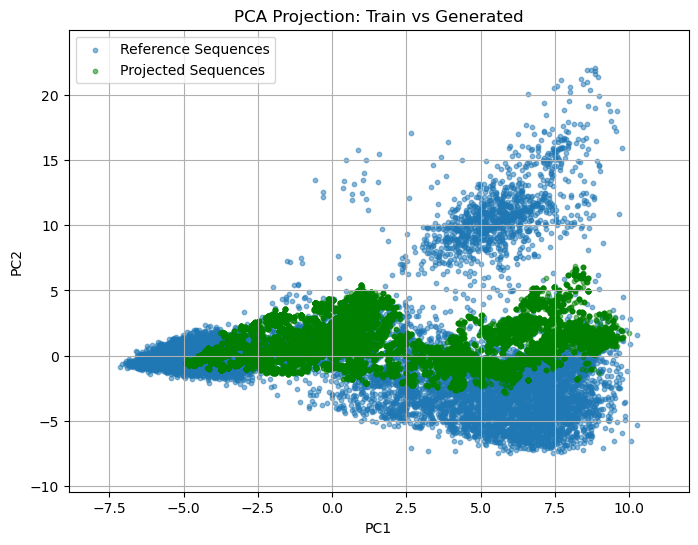

True seqs one-hot shape: (14502, 63, 21)
Gen  seqs one-hot shape: (20000, 63, 21)


In [ ]:
"""
    One-hot encode AA sequences - plm generated and true
"""
# -------------- Load generated sequences ----------------
#filename = 'gen_seqs_w_init_seq_Ns40000_r0.1'
#filename = 'generated_sequences_randinit_40000'
file_dir = 'mc_generated_sequences'
filename = 'mc_gen_seqs_w_init_seq_Ns100000_r0.1'

cwd = '/Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main'
#cwd=r'C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main'

# Load the generated sequences
output_file = cwd + f'/CODE/AttentionDCA_python/src/PLM/{file_dir}/{filename}.npy'
#output_file = cwd + f'\CODE\AttentionDCA_python\src\PLM\generated_sequences\{filename}.npy'
gen_sequences = np.load(output_file)
saved_seq = gen_sequences.copy()
Ni = 10000
Nf = 30000
gen_sequences = gen_sequences[Ni:Nf]


# -------------- Load train sequences ----------------
# Load train sequences
family = 'jdoms_bacteria_train2'
filename = cwd + f'/CODE/DataAttentionDCA/jdoms/{family}.fasta'

#filename = cwd + f'\CODE\DataAttentionDCA\jdoms\{family}.fasta'

train_sequences = sequences_from_fasta(filename)
train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]


plot_projected_pca(
    sequences_reference=train_sequences,
    sequences_to_project=gen_sequences,
    title="PCA Projection: Train vs Generated"
)

Loading: /Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main/CODE/AttentionDCA_python/src/PLM/generated_sequences/generated_sequences_randinit_40000.npy


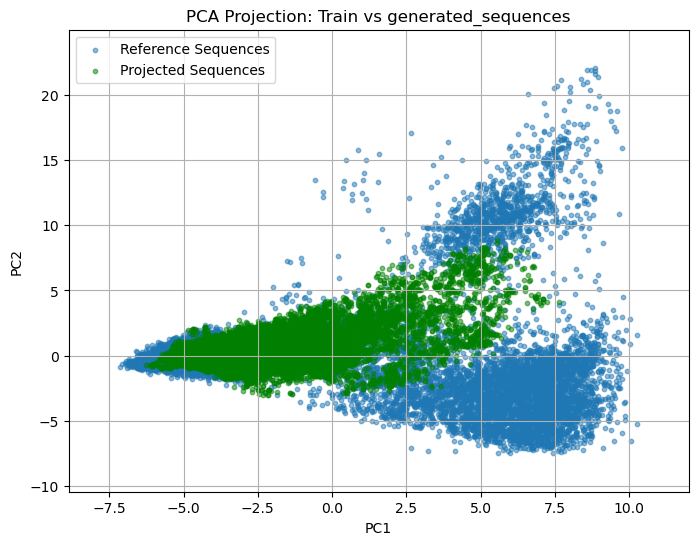

Saved PCA plot to: /Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main/CODE/AttentionDCA_python/src/PLM/results/PCA_plots/plm/generated_sequences_randinit_40000.pdf
Loading: /Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main/CODE/AttentionDCA_python/src/PLM/generated_sequences/gen_seqs_w_init_seq_Ns40000_r0.1.npy


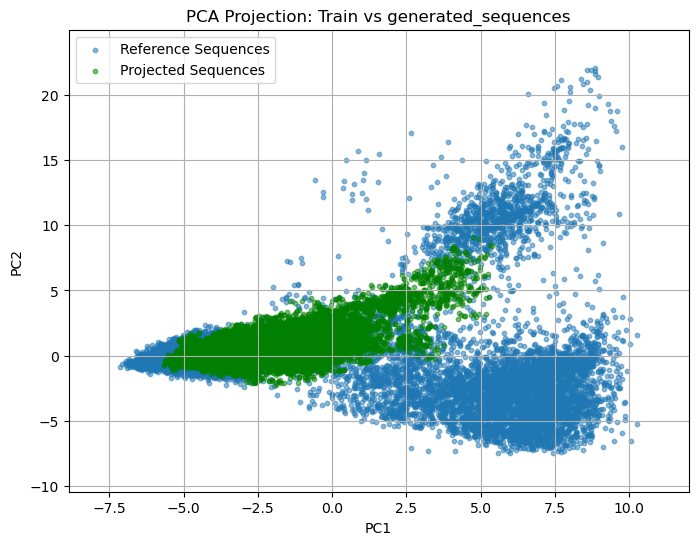

Saved PCA plot to: /Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main/CODE/AttentionDCA_python/src/PLM/results/PCA_plots/plm/gen_seqs_w_init_seq_Ns40000_r0.1.pdf
Loading: /Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main/CODE/AttentionDCA_python/src/PLM/mc_generated_sequences/mc_generated_sequences_randinit_300000.npy


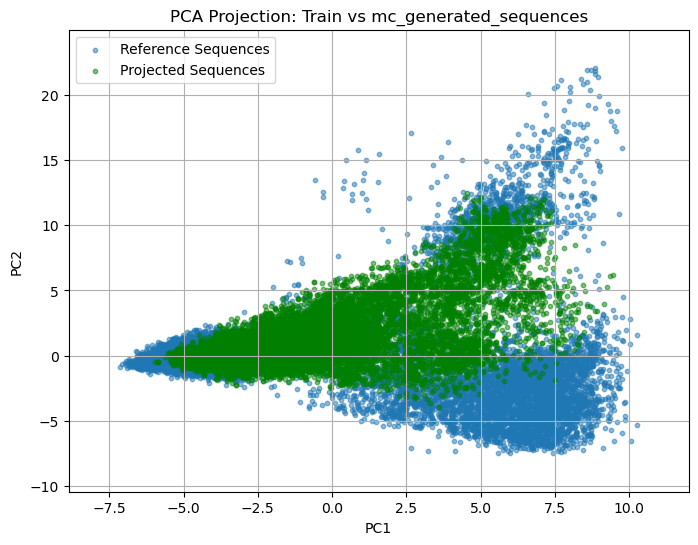

Saved PCA plot to: /Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main/CODE/AttentionDCA_python/src/PLM/results/PCA_plots/mc/mc_generated_sequences_randinit_300000.pdf
Loading: /Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main/CODE/AttentionDCA_python/src/PLM/mc_generated_sequences/mc_gen_seqs_w_init_seq_Ns100000_r0.1.npy


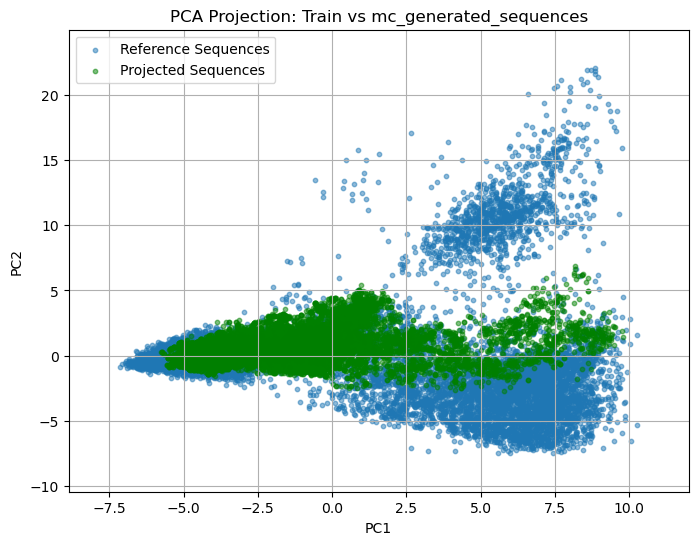

Saved PCA plot to: /Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main/CODE/AttentionDCA_python/src/PLM/results/PCA_plots/mc/mc_gen_seqs_w_init_seq_Ns100000_r0.1.pdf


In [9]:
file_map = {
    'generated_sequences_randinit_40000': 'generated_sequences',
    'gen_seqs_w_init_seq_Ns40000_r0.1': 'generated_sequences',
    'mc_generated_sequences_randinit_300000': 'mc_generated_sequences',
    'mc_gen_seqs_w_init_seq_Ns100000_r0.1': 'mc_generated_sequences'
}


for filename, dir in file_map.items():
    cwd = os.getcwd()
    save_subdir = 'plm' if dir == 'generated_sequences' else 'mc'
    save_path = os.path.join(cwd, 'results', 'PCA_plots', save_subdir)
    os.makedirs(save_path, exist_ok=True)

    cwd = '/Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main'
    output_file = os.path.join(cwd, 'CODE', 'AttentionDCA_python', 'src', 'PLM', dir, f'{filename}.npy')

    if os.path.exists(output_file):
        print(f"Loading: {output_file}")
        gen_sequences = np.load(output_file)
        # proceed with PCA or other processing...
    else:
        print(f"File not found: {output_file}")
    start_idx = 10000
    num_samples = len(train_sequences)
    gen_sequences = gen_sequences[start_idx:]
    
    # Uniformly sample indices
    indices = np.linspace(0, len(gen_sequences) - 1, num_samples, dtype=int)
    gen_sequences = gen_sequences[indices]
    save_name = save_path + f'/{filename}.pdf'
    plot_projected_pca(
        sequences_reference=train_sequences,
        sequences_to_project=gen_sequences,
        title=f"PCA Projection: Train vs {dir}",
        max_pot=21, save_path=save_name
    )
    print(f"Saved PCA plot to: {save_name}")